# Introducción al aprendizaje automatizado (O2026)
## Tutorial 10 - PCR, PLS y Modelos no lineales

**Objetivo:**
Que se familiaricen con métodos de regresión basados en reducción de la dimensionalidad (PCR & PLS) y modelos no lineales y semi-paramétricos

Esta tutorial es una adaptación del `Lab` de *Linear Models and Regularization Methods* del libro "Introduction to Statistical Learning with Applications in Python" por Gareth James, Daniela Witten, Trevor Hastie, Robert Tibshirani y Jonathan Taylor. [Acá](https://islp.readthedocs.io/en/latest/labs/Ch06-varselect-lab.html) pueden encontrar más información

### Métodos de Regresión basados en reducción de la dimensionalidad
El objetivo es buscar *transformar* los $p$ predictores y estimar una regresión lineal (por MCO) de $Y$ en los predictores transformados.

#### Regresión por Componentes Principales (PCR, principal component regression)

Para estimar por una regresión por componentes principales (PCR), primero, usamos `PCA` del modulo de [PCA() de Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). 
Luego, usamos la funcion conocida de `LinearRegression()` para estimar el modelo.

En este ejemplo, aplicamos PCR a los datos de [Hitters](https://islp.readthedocs.io/en/latest/datasets/Hitters.html) para predecir `Salary`.

In [3]:
# Importamos los paquetes necesarios
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

import sklearn.model_selection as skm

import sklearn.linear_model as skl
#from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

##### Preparamos los datos y transformamos variables

In [4]:
# Importamos los datos datos
Hitters = load_data('Hitters')
print(Hitters.info())
print('Dimensión de la base:', Hitters.shape, '\n')
#Vemos los missing values en Y
print('\nMissings en variable dependiente:', np.isnan(Hitters['Salary']).sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

In [5]:
# Visualizamos la estadistica descriptiva de la base
Hitters.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
AtBat,322.0,380.93,153.40,16.0,255.25,379.5,512.00,687.0
Hits,322.0,101.02,46.45,1.0,64.00,96.0,137.00,238.0
HmRun,322.0,10.77,8.71,0.0,4.00,8.0,16.00,40.0
Runs,322.0,50.91,26.02,0.0,30.25,48.0,69.00,130.0
RBI,322.0,48.03,26.17,0.0,28.00,44.0,64.75,121.0
Walks,322.0,38.74,21.64,0.0,22.00,35.0,53.00,105.0
Years,322.0,7.44,4.93,1.0,4.00,6.0,11.00,24.0
CAtBat,322.0,2648.68,2324.21,19.0,816.75,1928.0,3924.25,14053.0
CHits,322.0,717.57,654.47,4.0,209.00,508.0,1059.25,4256.0
CHmRun,322.0,69.49,86.27,0.0,14.00,37.5,90.00,548.0


In [6]:
# Eliminamos missings en la variable dependiente
Hitters = Hitters.dropna() 
print('\n Nueva dimensión de la base:', Hitters.shape)


 Nueva dimensión de la base: (263, 20)


Ahora preparamos nuestras variables - predicción del vector $y$, transformamos las variables string (como *League*) en dummies y creamos nuestra matriz de predictores $X$

In [7]:
y = Hitters.Salary
# Creamos variables dummies para las variables string
dummies = pd.get_dummies(Hitters[['League', 'Division', 'NewLeague']], drop_first=True)
dummies

# Eliminamos salarios (porque es nuestra y) y las columnas de strings
X_ = Hitters.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')
X = pd.concat([X_, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis=1)
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AtBat        263 non-null    float64
 1   Hits         263 non-null    float64
 2   HmRun        263 non-null    float64
 3   Runs         263 non-null    float64
 4   RBI          263 non-null    float64
 5   Walks        263 non-null    float64
 6   Years        263 non-null    float64
 7   CAtBat       263 non-null    float64
 8   CHits        263 non-null    float64
 9   CHmRun       263 non-null    float64
 10  CRuns        263 non-null    float64
 11  CRBI         263 non-null    float64
 12  CWalks       263 non-null    float64
 13  PutOuts      263 non-null    float64
 14  Assists      263 non-null    float64
 15  Errors       263 non-null    float64
 16  League_N     263 non-null    bool   
 17  Division_W   263 non-null    bool   
 18  NewLeague_N  263 non-null    bool   
dtypes: bool(3), f

Dividimos la base en observaciones para el entrenamiento y testeo


In [8]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

# Revisamos cuantas observaciones quedaron para Test y cuantas para Entrenamiento.
print(f'El conjunto de entrenamiento tiene {len(X_train)} observaciones.')
print(f'El conjunto de test tiene {len(X_test)} observaciones.')

El conjunto de entrenamiento tiene 210 observaciones.
El conjunto de test tiene 53 observaciones.


In [9]:
# Iniciamos el Standard Scaler
sc = StandardScaler()

# Estandarizamos las observaciones de entrenamiento
X_train_transformed = pd.DataFrame(sc.fit_transform(X_train), index=X_train.index, columns=X_train.columns)

# Estandarizamos las observaciones de test
X_test_transformed = pd.DataFrame(sc.transform(X_test), index=X_test.index, columns=X_test.columns)

# Estadisticas luego de estandarizar
X_train_transformed.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
AtBat,210.0,-0.0,1.0,-2.62,-0.84,0.08,0.82,1.95
Hits,210.0,-0.0,1.0,-2.38,-0.83,-0.10,0.77,2.92
HmRun,210.0,0.0,1.0,-1.34,-0.75,-0.29,0.65,3.33
Runs,210.0,-0.0,1.0,-2.14,-0.85,-0.07,0.70,2.94
RBI,210.0,-0.0,1.0,-2.02,-0.77,-0.17,0.80,2.79
Walks,210.0,0.0,1.0,-1.92,-0.73,-0.20,0.74,2.89
Years,210.0,-0.0,1.0,-1.28,-0.66,-0.25,0.57,3.45
CAtBat,210.0,-0.0,1.0,-1.12,-0.78,-0.34,0.56,4.95
CHits,210.0,0.0,1.0,-1.08,-0.79,-0.36,0.53,5.43
CHmRun,210.0,0.0,1.0,-0.82,-0.64,-0.34,0.19,5.85


#### Regresion por Componentes principales

Utilizamos la función [Pipeline()](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) de Sckit learn que permite en una forma clara, separar el paso de *transformar* los predictores y luego *estimar* el modelo de interés. 

In [10]:
pca = PCA(n_components=2)
linreg = skl.LinearRegression()
pipe = Pipeline([('pca', pca),
                 ('linreg', linreg)])
pipe.fit(X_train_transformed, y_train)
print(f'Los coeficientes de la regresión usando dos componentes principales son:')
print(pipe.named_steps['linreg'].coef_)

Los coeficientes de la regresión usando dos componentes principales son:
[93.62656031 16.60278318]


In [11]:
pipe.named_steps['pca'].components_.round(3)

array([[ 0.202,  0.195,  0.207,  0.196,  0.233,  0.204,  0.286,  0.329,
         0.329,  0.315,  0.335,  0.339,  0.316,  0.065,  0.012, -0.01 ,
        -0.092, -0.035, -0.076],
       [ 0.376,  0.375,  0.234,  0.376,  0.321,  0.213, -0.253, -0.192,
        -0.182, -0.137, -0.176, -0.17 , -0.194,  0.167,  0.182,  0.206,
        -0.1  , -0.05 , -0.078]])

Con el atributo `explained_variance_ratio_` de `PCA` podemos ver el porcentaje de la varianza explicada en los predictores y en la respuesta usando distinto número de componentes principales. 

In [12]:
pipe.named_steps['pca'].explained_variance_ratio_.round(2)

array([0.38, 0.22])

Esto nos dice la cantidad de informacion sobre los predictores que es caputara usando $M$ componentes. Esto nos muestra que usar $M=1$ caputa un 38% de la varianza, mientras que $M=2$ captura 22%.

##### Cross validation para elegir el número de componentes en PCR 
Podemos usar cross validation (CV) para buscar el número de componentes a utilizar en la regresión. Para eso, usaremos `skm.GridSearchCV`, donde el parámetro que varia es `n_components`.

In [13]:
# Usamos 5-fold cross-validation
K = 5
kfold = skm.KFold(K,
                  random_state=0,
                  shuffle=True)

# Definimos un rango de numero de componentes principales
param_grid = {'pca__n_components': range(1, 20)}


grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
#Estimamos
grid.fit(X_train_transformed, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('pca', PCA(n_components=2)),
                                       ('linreg', LinearRegression())]),
             param_grid={'pca__n_components': range(1, 20)},
             scoring='neg_mean_squared_error')

Ahora graficamos los resultados

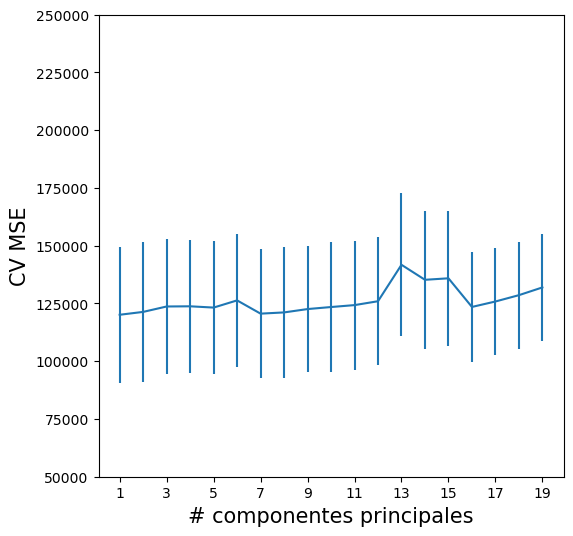

In [14]:
pcr_fig, ax = subplots(figsize=(6,6))
n_comp = param_grid['pca__n_components']
ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_ylabel('CV MSE', fontsize=15)
ax.set_xlabel('# componentes principales', fontsize=15)
ax.set_xticks(n_comp[::2])
ax.set_ylim([50000,250000]);

#### Minimos Cuadrados Parciales (Partial Least Squares, PLS)

Minimos Cuadrados Parciales (PLS) se implementa con la funcion [PLSRegression()](https://scikit-learn.org/stable/modules/generated/sklearn.cross_decomposition.PLSRegression.html)


In [18]:
pls = PLSRegression(n_components=2, 
                    scale=True)
pls.fit(X_train_transformed, y_train)

PLSRegression()

Similar al caso de PCR, usamos CV para elegir el numero de componentes

In [19]:
param_grid = {'n_components':range(1, 20)}

grid = skm.GridSearchCV(pls,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')

grid.fit(X_train_transformed, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=PLSRegression(),
             param_grid={'n_components': range(1, 20)},
             scoring='neg_mean_squared_error')

De la misma forma, en un graficamos el MSE por CV

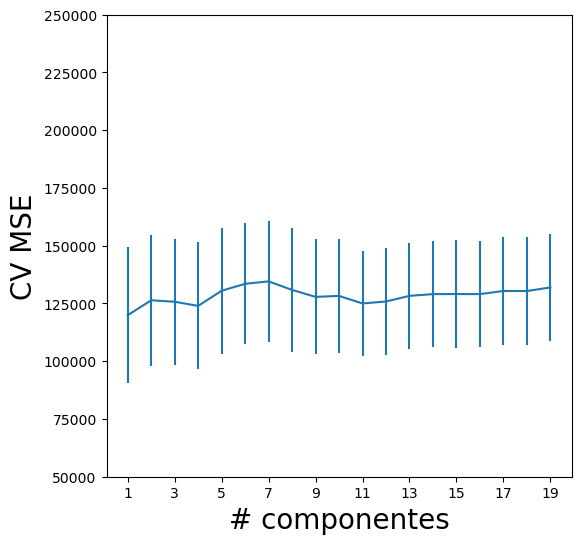

In [17]:
pls_fig, ax = subplots(figsize=(6,6))
n_comp = param_grid['n_components']
ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_ylabel('CV MSE', fontsize=20)
ax.set_xlabel('# componentes', fontsize=20)
ax.set_xticks(n_comp[::2])
ax.set_ylim([50000,250000]);

In [20]:
min_index = np.argmin(-grid.cv_results_['mean_test_score'])
print("El menor MSE es para " + str(min_index + 1) + " componente, y vale " + str(-grid.cv_results_['mean_test_score'][min_index]))


El menor MSE es para 1 componente, y vale 119900.9521372111


# Modelos no lineales
En el curso nos enfocamos principalmente en modelos lineales, por ser simples y por sus ventajas en términos de interpretabilidad e inferencia

Sin embargo, el supuesto de linealidad es fuerte y a veces puede llevar a un menor poder predictivo. Ahora vamos a relajar el supuesto de linealidad.

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.pyplot import subplots
from ISLP import load_data
#%matplotlib inline

from sklearn import metrics
from sklearn.metrics import mean_squared_error, accuracy_score, r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

En este ejemplo, aplicamos los modelos no lineales a los datos de [Wage](https://islp.readthedocs.io/en/latest/datasets/Wage.html) (que contiene datos de 3000 hombres trabajadores de la region del Atlantico Medio en EEUU) para predecir `wage` (*workers raw wage*).

In [22]:
dataset = load_data('Wage')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        3000 non-null   int64   
 1   age         3000 non-null   int64   
 2   maritl      3000 non-null   category
 3   race        3000 non-null   category
 4   education   3000 non-null   category
 5   region      3000 non-null   category
 6   jobclass    3000 non-null   category
 7   health      3000 non-null   category
 8   health_ins  3000 non-null   category
 9   logwage     3000 non-null   float64 
 10  wage        3000 non-null   float64 
dtypes: category(7), float64(2), int64(2)
memory usage: 115.5 KB


In [23]:
# Vamos a usar salario y edad
X = dataset['age']
y = dataset['wage']
print(y)

0        75.043154
1        70.476020
2       130.982177
3       154.685293
4        75.043154
           ...    
2995    154.685293
2996     99.689464
2997     66.229408
2998     87.981033
2999     90.481913
Name: wage, Length: 3000, dtype: float64


Text(0, 0.5, 'Wage')

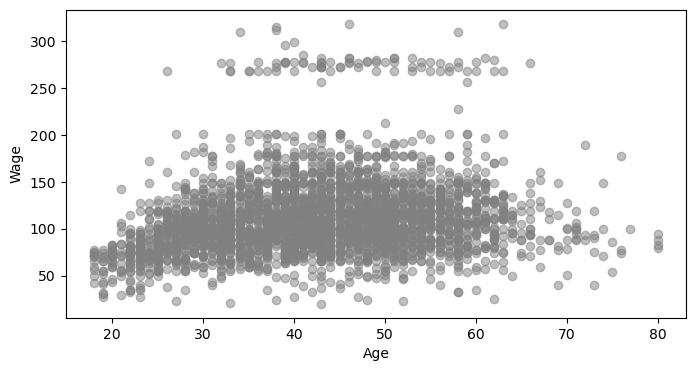

In [24]:
fig, ax = subplots(figsize=(8,4))
ax.scatter(X, y, facecolor='gray', alpha=0.5)
ax.set_xlabel('Age')
ax.set_ylabel('Wage')


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#### Regresión polinómica

In [26]:
# Reshape para transformar x en un vector columna
X_train_ = X_train.values.reshape((-1, 1)) # Convertir Series a NumPy array y reshape

# Transformación polinomial
model_pol = PolynomialFeatures(include_bias=True, degree=4)
model_pol.fit(X_train_)
X_train_t = model_pol.transform(X_train_)

# Si en PolynomialFeatures ponemos include_bias=False, podemos agregar constante:
#X_train_t = sm.add_constant(X_train_t)

# Especificamos el modelo y ajustamos
model_pol4 = sm.OLS(y_train, X_train_t)
results = model_pol4.fit()

print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     53.66
Date:                Tue, 26 May 2026   Prob (F-statistic):           2.31e-43
Time:                        15:59:21   Log-Likelihood:                -12199.
No. Observations:                2400   AIC:                         2.441e+04
Df Residuals:                    2395   BIC:                         2.444e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -129.0543     65.010     -1.985      0.0

Estimamos el MSE de testeo

In [28]:
X_test_t = model_pol.fit_transform(X_test.values.reshape((-1, 1)))

y_pred = results.predict(X_test_t)

print('ECM:', mean_squared_error(y_test, y_pred))

ECM: 1866.7237807749937


Text(0, 0.5, 'Wage')

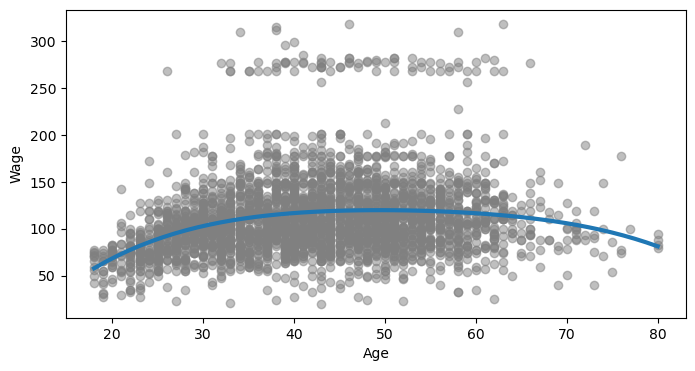

In [29]:
# Generamos otras X y sus predicciones para graficar
X_seq = np.linspace(X.min(), X.max()).reshape(-1,1)
X_seq_t = model_pol.fit_transform(X_seq)
X_seq_pred = results.predict(X_seq_t)

fig, ax = subplots(figsize=(8,4))
ax.scatter(X, y, facecolor='gray', alpha=0.5)
ax.plot(X_seq, X_seq_pred, label='Reg. polinómica grado 4', linewidth=3)
ax.set_xlabel('Age')
ax.set_ylabel('Wage')
#ax.legend(title='Poly', fontsize=15)


In [30]:
results.predict(X_seq_t)

array([ 57.79723124,  64.68372044,  70.98053724,  76.72437484,
        81.95052647,  86.69288549,  90.98394527,  94.85479928,
        98.33514105, 101.45326418, 104.23606235, 106.70902928,
       108.89625878, 110.82044472, 112.50288105, 113.96346178,
       115.22068098, 116.29163281, 117.19201147, 117.93611126,
       118.53682652, 119.00565168, 119.35268122, 119.58660971,
       119.71473177, 119.74294209, 119.67573544, 119.51620665,
       119.26605062, 118.92556231, 118.49363678, 117.96776911,
       117.34405449, 116.61718815, 115.78046541, 114.82578165,
       113.74363232, 112.52311292, 111.15191905, 109.61634636,
       107.90129057, 105.99024747, 103.86531292, 101.50718284,
        98.89515323,  96.00712016,  92.81957975,  89.30762821,
        85.4449618 ,  81.20387687])

Podemos elegir el grado del polinimio por CV

**Tarea:** revisar tutorial 10 de cross-validation para elegir el grado del polinomio optimo

#### Step function

In [31]:
# Hacemos a la edad (X) discreta en función de quintiles
cut_X = pd.qcut(X, 4) #qcut con 4 quintiles
cut_X
# Nota pd.cut() permitiría hacer cortes no basados en quintiles

0       (17.999, 33.75]
1       (17.999, 33.75]
2          (42.0, 51.0]
3          (42.0, 51.0]
4          (42.0, 51.0]
             ...       
2995       (42.0, 51.0]
2996    (17.999, 33.75]
2997    (17.999, 33.75]
2998    (17.999, 33.75]
2999       (51.0, 80.0]
Name: age, Length: 3000, dtype: category
Categories (4, interval[float64, right]): [(17.999, 33.75] < (33.75, 42.0] < (42.0, 51.0] < (51.0, 80.0]]

In [32]:
# y creamos dummies para cada quintil
q_X = pd.get_dummies(cut_X)
q_X

,"(17.999, 33.75]","(33.75, 42.0]","(42.0, 51.0]","(51.0, 80.0]"
0,True,False,False,False
1,True,False,False,False
2,False,False,True,False
3,False,False,True,False
4,False,False,True,False
...,...,...,...,...
2995,False,False,True,False
2996,True,False,False,False
2997,True,False,False,False
2998,True,False,False,False


In [33]:
# Primera columna
q_X.iloc[:, 0]

0        True
1        True
2       False
3       False
4       False
        ...  
2995    False
2996     True
2997     True
2998     True
2999    False
Name: (17.999, 33.75], Length: 3000, dtype: bool

In [34]:
q_X_train, q_X_test, y_train, y_test = train_test_split(q_X, y, test_size=0.2, random_state=0)

In [35]:
#q_X_train_= sm.add_constant(q_X_train)

# Especificamos el modelo y ajustamos
q_model_pol4 = sm.OLS(y_train, q_X_train)
q_results = q_model_pol4.fit()

print(q_results.summary())


                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     48.50
Date:                Tue, 26 May 2026   Prob (F-statistic):           1.99e-30
Time:                        16:00:17   Log-Likelihood:                -12231.
No. Observations:                2400   AIC:                         2.447e+04
Df Residuals:                    2396   BIC:                         2.449e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
(17.999, 33.75]    95.0799      1.613     

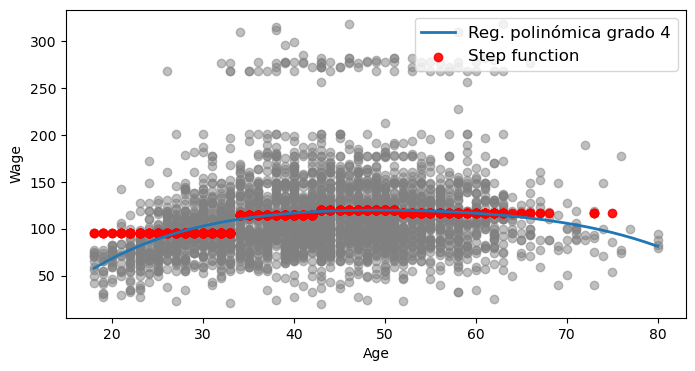

In [36]:
q_pred =  q_results.predict(q_X_test).values

fig, ax = subplots(figsize=(8,4))
ax.scatter(X, y, facecolor='gray', alpha=0.5)
ax.plot(X_seq, results.predict(X_seq_t), label='Reg. polinómica grado 4', linewidth=2)
ax.scatter(X_test.values.reshape(-1,1), q_pred, facecolor='red', alpha=0.9, label="Step function")
ax.set_xlabel('Age')
ax.set_ylabel('Wage')
ax.legend(title='', fontsize=12)

#### Splines
Idea: usar polinomios y step function

Se determinan puntos de corte (knots) en $X$ y se ajustan distintas regresiones para cada segmento.

In [37]:
print('Min age:', min(dataset['age']), 'Max age:', max(dataset['age']))

Min age: 18 Max age: 80


In [38]:
from scipy.interpolate import BSpline

Usamos la funcion [BSpline()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.BSpline.html) del modulo de `scipy`

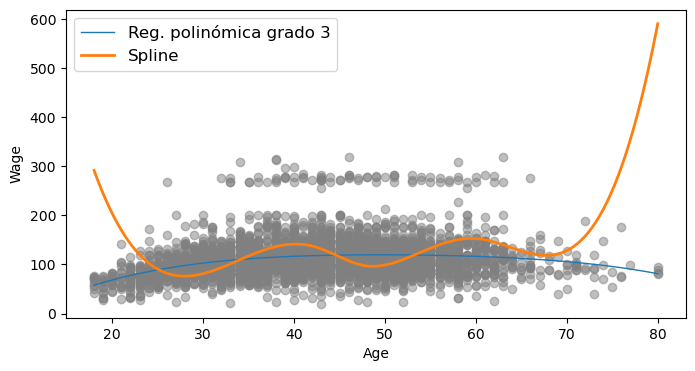

In [39]:
# Definimos knots y grado del polinomio
knots=[18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78]
degree=3
t = [min(dataset['age'])] + knots + [max(dataset['age'])]
spl = BSpline(t, list(dataset['wage']), degree)

# Grilla para evaluar spline
x_smooth = np.linspace(min(dataset['age']), max(dataset['age']), 300)
y_smooth = spl(x_smooth)

# Plot
fig, ax = subplots(figsize=(8,4))
ax.scatter(X, y, facecolor='gray', alpha=0.5)
ax.plot(X_seq, results.predict(X_seq_t), label='Reg. polinómica grado 3', linewidth=1)
ax.plot(x_smooth, y_smooth, label='Spline', linewidth=2)
ax.set_xlabel('Age')
ax.set_ylabel('Wage')
ax.legend(title='', fontsize=12)


#### Regresión Local

Usamos función [lowess](https://www.statsmodels.org/stable/generated/statsmodels.nonparametric.smoothers_lowess.lowess.html#statsmodels.nonparametric.smoothers_lowess.lowess) de set de funciones no paramétricas de Statsmodels. Esta es una regresión local por Kernels, donde la funcion de Kernels elegida es *tricúbica*.

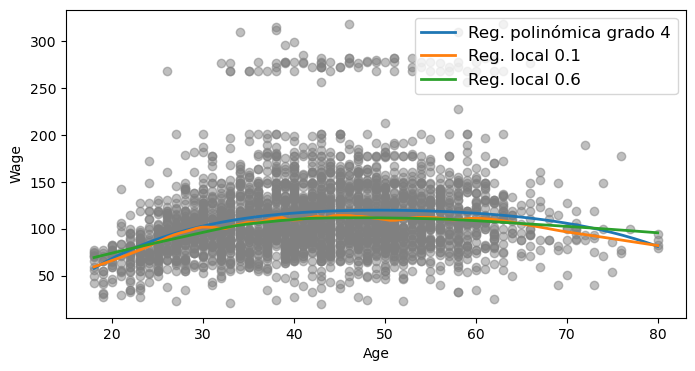

In [40]:
import statsmodels as sm

X = dataset['age']
y = dataset['wage']
age_grid = np.linspace(X.min(), X.max(), 100)


lowess = sm.nonparametric.smoothers_lowess.lowess

spans = [0.1, 0.6]
# spans de 0.1 and 0.6. Se consideran 10% o 60% de las observaciones vecinas

# Plot
fig, ax = subplots(figsize=(8,4))
ax.scatter(X, y, facecolor='gray', alpha=0.5)
ax.plot(X_seq, results.predict(X_seq_t), label='Reg. polinómica grado 4', linewidth=2)
for span in spans:
    fitted = lowess(y, X, frac=span, xvals=age_grid)
    ax.plot(age_grid, fitted, label='Reg. local {:.1f}'.format(span), linewidth=2)
ax.set_xlabel('Age')
ax.set_ylabel('Wage')
ax.legend(title='', fontsize=12)



Podemos notar que con span de 0.6 es más suave

---

### Comparación de performance: MSE test

Hasta acá vimos cuatro métodos no lineales (polinomio, step function, spline, LOWESS). La pregunta natural es: **¿cuánto mejora cada uno respecto del baseline lineal (MCO)?**

Calculamos el **MSE en el conjunto de test** (`random_state=0`, 20% holdout) para cada método y los comparamos contra el OLS lineal en una sola tabla.

In [42]:
# === Comparación de performance: MSE test (Wage: age -> wage) ===
# Comparamos los métodos no lineales contra el baseline MCO (OLS lineal).
# Usamos los mismos splits que arriba (random_state=0).

import statsmodels.api as smapi  # re-importamos por si fue sombrado más arriba
from statsmodels.nonparametric.smoothers_lowess import lowess as _lowess
from sklearn.preprocessing import SplineTransformer

# Reshape de X_train, X_test (Series -> array 2D) para sklearn/statsmodels
X_tr = X_train.values.reshape(-1, 1)
X_te = X_test.values.reshape(-1, 1)

# 1) OLS lineal (baseline)
X_tr_lin = smapi.add_constant(X_tr)
X_te_lin = smapi.add_constant(X_te)
mse_lin = mean_squared_error(y_test, smapi.OLS(y_train, X_tr_lin).fit().predict(X_te_lin))

# 2) Polinomio grado 4
poly = PolynomialFeatures(degree=4, include_bias=True)
X_tr_p = poly.fit_transform(X_tr)
X_te_p = poly.transform(X_te)
mse_poly = mean_squared_error(y_test, smapi.OLS(y_train, X_tr_p).fit().predict(X_te_p))

# 3) Step function (4 cuantiles definidos en TRAIN, aplicados a TEST)
bins = pd.qcut(X_train, 4, retbins=True)[1]
bins[0], bins[-1] = -np.inf, np.inf  # extendemos las colas para no perder obs en test
q_tr = pd.get_dummies(pd.cut(X_train, bins)).astype(float)
q_te = pd.get_dummies(pd.cut(X_test, bins)).astype(float)
q_te = q_te.reindex(columns=q_tr.columns, fill_value=0.0)  # alineamos columnas
mse_step = mean_squared_error(y_test, smapi.OLS(y_train, q_tr).fit().predict(q_te))

# 4) Spline cúbico de regresión (basis B-spline + OLS sobre el basis)
#    Ojo: distinto del BSpline interpolante que vimos arriba (ese era solo para visualizar).
spl_t = SplineTransformer(degree=3, n_knots=11, knots='uniform')
X_tr_s = spl_t.fit_transform(X_tr)
X_te_s = spl_t.transform(X_te)
mse_spl = mean_squared_error(y_test, smapi.OLS(y_train, X_tr_s).fit().predict(X_te_s))

# 5) LOWESS (span=0.6): ajustamos en train y evaluamos en los X de test
y_pred_lo = _lowess(y_train, X_train, frac=0.6, xvals=X_test.values)
mse_lo = mean_squared_error(y_test, y_pred_lo)

# Tabla resumen
comparacion = pd.DataFrame({
    'Método': ['OLS lineal (baseline)',
               'Polinomio grado 4',
               'Step function (4 cuantiles)',
               'Spline cúbico (11 nudos)',
               'LOWESS (span = 0.6)'],
    'MSE test': [mse_lin, mse_poly, mse_step, mse_spl, mse_lo]
}).round(2)
comparacion['Δ vs OLS (%)'] = ((comparacion['MSE test'] - mse_lin) / mse_lin * 100).round(2)
comparacion

,Método,MSE test,Δ vs OLS (%)
0,OLS lineal (baseline),1983.46,-0.00
1,Polinomio grado 4,1866.72,-5.89
2,Step function (4 cuantiles),1938.05,-2.29
3,Spline cúbico (11 nudos),1863.45,-6.05
4,LOWESS (span = 0.6),1945.04,-1.94


**Lectura:**

- **OLS lineal** es nuestro *baseline*: asume $E[Y \mid X] = \beta_0 + \beta_1 \cdot \text{age}$, lo cual claramente está mal especificado (la relación edad–salario es cóncava: sube hasta los 40 y baja después).
- Cada método no lineal **reduce el MSE test** respecto al *baseline*. La columna **Δ vs OLS (%)** muestra el porcentaje de mejora (valor negativo $\Rightarrow$ mejor que MCO).
- Las diferencias **entre** los métodos no lineales son chicas: en este problema, lo que más mueve la aguja es **dejar de imponer linealidad**, no qué herramienta no lineal específica elegimos.
- En un trabajo aplicado el siguiente paso sería elegir el **grado del polinomio**, el **número de nudos** del spline o el **span** de LOWESS por **cross-validation** (no a ojo, como hicimos acá).